# Predicción de un producto cotizado con redes neuronales recurrentes

En este notebook se analiza **SAN.MC (Banco Santander)** usando el **precio de cierre** y comparando modelos recurrentes con experimentos reproducibles.

## Requisitos
- Misma semilla para todos los modelos.
- Uso del precio de cierre (`Close`).
- Modelos con API secuencial y funcional de Keras.
- Pruebas con LSTM y GRU, variando capas y neuronas.
- Pruebas con distintas ventanas temporales (`n_steps`).
- Pruebas con optimizadores RMSprop y Adam.
- Valoración final de resultados con RMSE, MAE y MAPE.

## 1) Instalación de dependencias

In [4]:
%pip -q install yfinance


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2) Importaciones y configuración de semilla

In [5]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from tensorflow.keras import Model, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU
from tensorflow.keras.optimizers import RMSprop, Adam
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42

def set_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds()
print('Semilla fija:', SEED)

Semilla fija: 42


In [6]:
# Mostrar la versión de TensorFlow
print("TensorFlow version:", tf.__version__)

# Detectar GPUs disponibles
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU(s) detectada(s):")
    for gpu in gpus:
        print(" -", gpu)
else:
    print("No se detectaron GPUs.")

TensorFlow version: 2.16.1
GPU(s) detectada(s):
 - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## 3) Descarga y preparación de datos (`Close`)

In [7]:
ticker = 'SAN.MC'
start_date = '2015-01-01'
end_date = '2026-01-01'

df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False, progress=False)
if df.empty:
    raise ValueError('No se pudieron descargar datos. Revisa conexión o el ticker.')

close_series = df[['Close']].dropna().copy()
close_series.columns = ['close']

print(close_series.head())
print(close_series.tail())
print('\nRegistros:', len(close_series))

               close
Date                
2015-01-02  6.627242
2015-01-05  6.324676
2015-01-06  6.214394
2015-01-07  6.253982
2015-01-08  6.462291
             close
Date              
2025-12-23  10.002
2025-12-24   9.989
2025-12-29   9.966
2025-12-30  10.126
2025-12-31  10.070

Registros: 2814


## 4) Visualización de la serie temporal

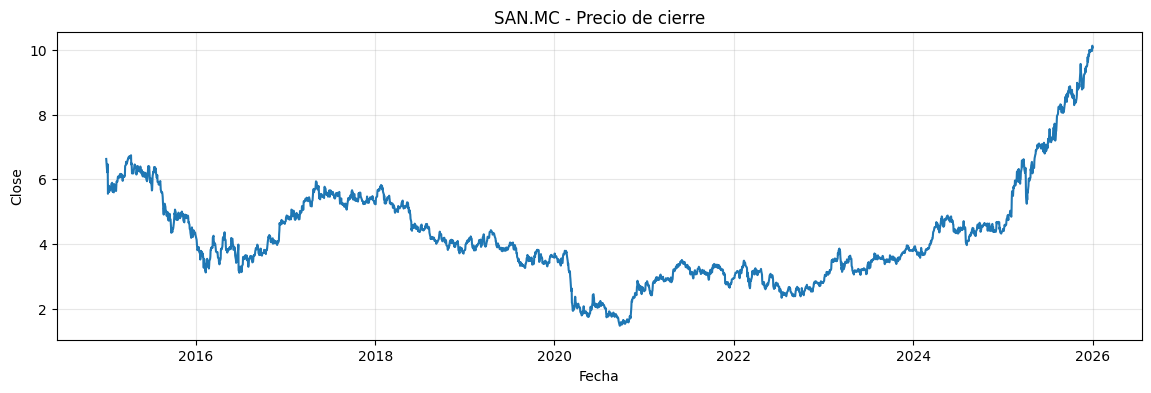

In [8]:
plt.figure(figsize=(14, 4))
plt.plot(close_series.index, close_series['close'], color='tab:blue')
plt.title(f'{ticker} - Precio de cierre')
plt.xlabel('Fecha')
plt.ylabel('Close')
plt.grid(alpha=0.3)
plt.show()

## 5) Funciones de preprocesado y métricas

In [9]:
# Función para dividir la serie en conjuntos de entrenamiento y prueba
def train_test_split_series(series_df, train_ratio=0.8):
    split_idx = int(len(series_df) * train_ratio)
    train_df = series_df.iloc[:split_idx].copy()
    test_df = series_df.iloc[split_idx:].copy()
    return train_df, test_df

# Función para crear secuencias de datos para entrenamiento y prueba
def make_sequences(values, n_steps):
    X, y = [], []
    for i in range(n_steps, len(values)):
        X.append(values[i - n_steps:i])
        y.append(values[i])
    X = np.array(X)
    y = np.array(y)
    return X, y

# Función para preparar los datos para los modelos de series temporales
def prepare_data_for_steps(close_df, n_steps=60):
    train_df, test_df = train_test_split_series(close_df, train_ratio=0.8)
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_df[['close']])

    test_input = pd.concat([train_df[['close']].tail(n_steps), test_df[['close']]], axis=0)
    test_scaled = scaler.transform(test_input)

    X_train, y_train = make_sequences(train_scaled, n_steps)
    X_test, y_test = make_sequences(test_scaled, n_steps)

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)
    test_index = test_df.index

    return X_train, y_train, X_test, y_test, y_test_real, scaler, test_index

# Función para calcular métricas de evaluación
def compute_metrics(y_real, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_real, y_pred)))
    mae = float(mean_absolute_error(y_real, y_pred))
    mape = float(mean_absolute_percentage_error(y_real, y_pred) * 100)
    return rmse, mae, mape

## 6) Construcción de modelos (API secuencial y funcional)

In [10]:
def get_optimizer(name, lr=0.001):
    if name.lower() == 'rmsprop':
        return RMSprop(learning_rate=lr)
    if name.lower() == 'adam':
        return Adam(learning_rate=lr)
    raise ValueError(f'Optimizador no soportado: {name}')

# Función para construir un modelo secuencial
def build_sequential_model(cell_type='lstm', units=(64,), n_steps=60, optimizer='adam'):
    set_seeds()
    model = Sequential()
    for i, u in enumerate(units):
        return_sequences = i < len(units) - 1
        if cell_type.lower() == 'lstm':
            if i == 0:
                model.add(LSTM(u, return_sequences=return_sequences, input_shape=(n_steps, 1)))
            else:
                model.add(LSTM(u, return_sequences=return_sequences))
        elif cell_type.lower() == 'gru':
            if i == 0:
                model.add(GRU(u, return_sequences=return_sequences, input_shape=(n_steps, 1)))
            else:
                model.add(GRU(u, return_sequences=return_sequences))
        else:
            raise ValueError(f'cell_type no soportado: {cell_type}')
    model.add(Dense(1))
    model.compile(optimizer=get_optimizer(optimizer), loss='mse')
    return model

# Función para construir un modelo funcional
def build_functional_model(cell_type='lstm', units=(64,), n_steps=60, optimizer='adam'):
    set_seeds()
    inputs = Input(shape=(n_steps, 1))
    x = inputs
    for i, u in enumerate(units):
        return_sequences = i < len(units) - 1
        if cell_type.lower() == 'lstm':
            x = LSTM(u, return_sequences=return_sequences)(x)
        elif cell_type.lower() == 'gru':
            x = GRU(u, return_sequences=return_sequences)(x)
        else:
            raise ValueError(f'cell_type no soportado: {cell_type}')
    outputs = Dense(1)(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=get_optimizer(optimizer), loss='mse')
    return model

## 7) Ejecución de pruebas

In [11]:
# Función para ejecutar pruebas con una configuración dada
def run_tests(close_df, cfg, epochs=30, batch_size=32):
    X_train, y_train, X_test, y_test, y_test_real, scaler, test_index = prepare_data_for_steps(close_df, n_steps=cfg['n_steps'])

    if cfg['api'] == 'sequential':
        model = build_sequential_model(
            cell_type=cfg['cell_type'],
            units=cfg['units'],
            n_steps=cfg['n_steps'],
            optimizer=cfg['optimizer']
        )
    else:
        model = build_functional_model(
            cell_type=cfg['cell_type'],
            units=cfg['units'],
            n_steps=cfg['n_steps'],
            optimizer=cfg['optimizer']
        )

    set_seeds()
    
    # Se utiliza EarlyStopping para evitar sobreajuste y restaurar los mejores pesos
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    # history representa el historial de entrenamiento, incluyendo las pérdidas por época
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[es],
        verbose=0
    )

    # Obtenemos las predicciones del modelo y las transformamos de nuevo a la escala original
    # Luego calculamos las métricas de evaluación
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred_real = scaler.inverse_transform(y_pred_scaled).reshape(-1)
    rmse, mae, mape = compute_metrics(y_test_real, y_pred_real)

    result = {
        'api': cfg['api'],
        'cell_type': cfg['cell_type'],
        'units': str(cfg['units']),
        'n_steps': cfg['n_steps'],
        'optimizer': cfg['optimizer'],
        'epochs_trained': len(history.history['loss']),
        'rmse': rmse,
        'mae': mae,
        'mape': mape
    }

    artifacts = {
        'model': model,
        'y_real': y_test_real,
        'y_pred': y_pred_real,
        'test_index': test_index
    }

    return result, artifacts

experiments = [
    {'api': 'sequential', 'cell_type': 'lstm', 'units': (64,), 'n_steps': 30, 'optimizer': 'RMSprop'},
    {'api': 'sequential', 'cell_type': 'lstm', 'units': (128, 64), 'n_steps': 60, 'optimizer': 'Adam'},
    {'api': 'functional', 'cell_type': 'lstm', 'units': (64,), 'n_steps': 60, 'optimizer': 'RMSprop'},
    {'api': 'functional', 'cell_type': 'lstm', 'units': (128, 64), 'n_steps': 30, 'optimizer': 'Adam'},
    {'api': 'sequential', 'cell_type': 'gru', 'units': (64,), 'n_steps': 30, 'optimizer': 'Adam'},
    {'api': 'sequential', 'cell_type': 'gru', 'units': (128, 64), 'n_steps': 60, 'optimizer': 'RMSprop'},
    {'api': 'functional', 'cell_type': 'gru', 'units': (64,), 'n_steps': 60, 'optimizer': 'Adam'},
    {'api': 'functional', 'cell_type': 'gru', 'units': (128, 64), 'n_steps': 30, 'optimizer': 'RMSprop'}
]

results = []
artifacts_by_exp = []

for i, cfg in enumerate(experiments, start=1):
    print(f'Experimento {i}/{len(experiments)} -> {cfg}')
    result, artifacts = run_tests(close_series, cfg, epochs=30, batch_size=32)
    results.append(result)
    artifacts_by_exp.append(artifacts)

Experimento 1/8 -> {'api': 'sequential', 'cell_type': 'lstm', 'units': (64,), 'n_steps': 30, 'optimizer': 'RMSprop'}


2026-03-11 09:17:44.716781: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-11 09:17:44.721640: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-11 09:17:44.722983: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Experimento 2/8 -> {'api': 'sequential', 'cell_type': 'lstm', 'units': (128, 64), 'n_steps': 60, 'optimizer': 'Adam'}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:205: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Experimento 3/8 -> {'api': 'functional', 'cell_type': 'lstm', 'units': (64,), 'n_steps': 60, 'optimizer': 'RMSprop'}
Experimento 4/8 -> {'api': 'functional', 'cell_type': 'lstm', 'units': (128, 64), 'n_steps': 30, 'optimizer': 'Adam'}
Experimento 5/8 -> {'api': 'sequential', 'cell_type': 'gru', 'units': (64,), 'n_steps': 30, 'optimizer': 'Adam'}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:205: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Experimento 6/8 -> {'api': 'sequential', 'cell_type': 'gru', 'units': (128, 64), 'n_steps': 60, 'optimizer': 'RMSprop'}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:205: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Experimento 7/8 -> {'api': 'functional', 'cell_type': 'gru', 'units': (64,), 'n_steps': 60, 'optimizer': 'Adam'}
Experimento 8/8 -> {'api': 'functional', 'cell_type': 'gru', 'units': (128, 64), 'n_steps': 30, 'optimizer': 'RMSprop'}


## 8) Ranking de resultados

In [12]:
# Convertimos los resultados a un DataFrame para mejor visualización y análisis
# MAPE representa la desviación porcentual entre las predicciones y los valores reales
results_df = pd.DataFrame(results).sort_values('rmse').reset_index(drop=True)
results_df

,api,cell_type,units,n_steps,optimizer,epochs_trained,rmse,mae,mape
0,functional,gru,"(64,)",60,Adam,27,0.114957,0.081351,1.439075
1,sequential,gru,"(64,)",30,Adam,30,0.118255,0.086276,1.505439
2,functional,lstm,"(64,)",60,RMSprop,30,0.127574,0.089222,1.607353
3,sequential,gru,"(128, 64)",60,RMSprop,24,0.151104,0.110190,1.868562
4,sequential,lstm,"(128, 64)",60,Adam,30,0.161700,0.122695,2.064411
5,functional,lstm,"(128, 64)",30,Adam,30,0.216852,0.175244,2.953406
6,sequential,lstm,"(64,)",30,RMSprop,30,0.235710,0.196738,3.390179
7,functional,gru,"(128, 64)",30,RMSprop,30,0.339023,0.299416,5.177353


## 9) Selección de la mejor configuración

In [13]:
# Aquí buscamos al mejor modelo según el RMSE y recuperamos sus artefactos para análisis posterior
best_cfg = results_df.iloc[0].to_dict()

def same_cfg(result_row, cfg_row):
    return (
        result_row['api'] == cfg_row['api'] and
        result_row['cell_type'] == cfg_row['cell_type'] and
        result_row['units'] == cfg_row['units'] and
        result_row['n_steps'] == cfg_row['n_steps'] and
        result_row['optimizer'] == cfg_row['optimizer']
    )

best_artifacts = None
for res, art in zip(results, artifacts_by_exp):
    if same_cfg(res, best_cfg):
        best_artifacts = art
        break

print('Mejor configuración encontrada:')
print(best_cfg)

Mejor configuración encontrada:
{'api': 'functional', 'cell_type': 'gru', 'units': '(64,)', 'n_steps': 60, 'optimizer': 'Adam', 'epochs_trained': 27, 'rmse': 0.11495659364268572, 'mae': 0.08135113114785554, 'mape': 1.439075114577981}


## 10) Comparación real vs predicción (mejor modelo)

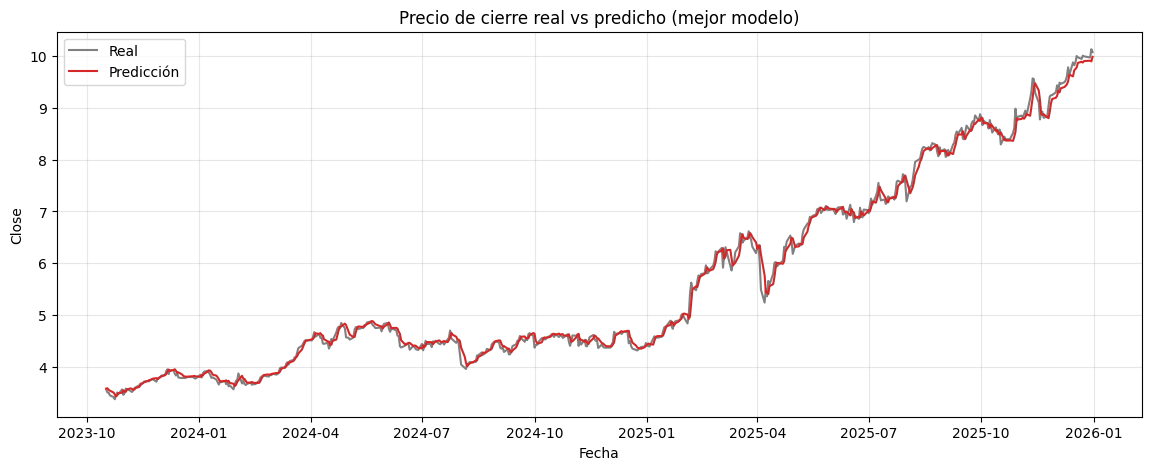

In [14]:
y_real = best_artifacts['y_real']
y_pred = best_artifacts['y_pred']
test_index = best_artifacts['test_index']

plt.figure(figsize=(14, 5))
plt.plot(test_index, y_real, label='Real', color='gray')
plt.plot(test_index, y_pred, label='Predicción', color='tab:red')
plt.title('Precio de cierre real vs predicho (mejor modelo)')
plt.xlabel('Fecha')
plt.ylabel('Close')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 11) Predicción de próximos días hábiles

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


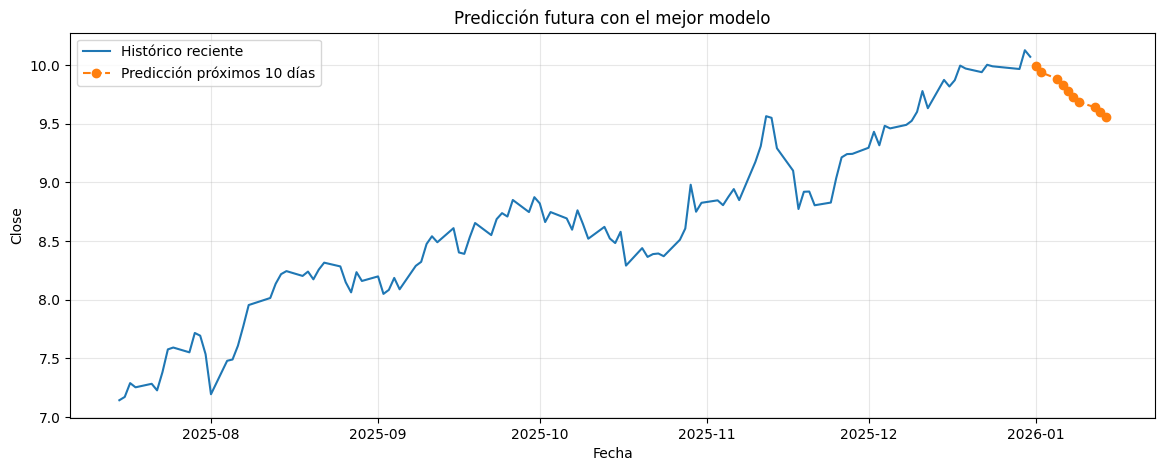

,fecha,pred_close
0,2026-01-01,9.988761
1,2026-01-02,9.937230
2,2026-01-05,9.882667
3,2026-01-06,9.830019
4,2026-01-07,9.779445
5,2026-01-08,9.731034
6,2026-01-09,9.684569
7,2026-01-12,9.639973
8,2026-01-13,9.597221
9,2026-01-14,9.555902


In [15]:
best_n_steps = int(best_cfg['n_steps'])
best_model = best_artifacts['model']

X_train, y_train, X_test, y_test, y_test_real, scaler_best, test_index_best = prepare_data_for_steps(close_series, n_steps=best_n_steps)

n_future = 10
last_window = close_series[['close']].values[-best_n_steps:]
last_window_scaled = scaler_best.transform(last_window)

future_scaled = []
window = last_window_scaled.copy()

for _ in range(n_future):
    x_input = window.reshape(1, best_n_steps, 1)
    next_scaled = best_model.predict(x_input, verbose=0)[0, 0]
    future_scaled.append(next_scaled)
    window = np.vstack([window[1:], [[next_scaled]]])

future_prices = scaler_best.inverse_transform(np.array(future_scaled).reshape(-1, 1)).reshape(-1)
future_index = pd.bdate_range(start=close_series.index[-1] + pd.Timedelta(days=1), periods=n_future)

plt.figure(figsize=(14, 5))
plt.plot(close_series.index[-120:], close_series['close'].values[-120:], label='Histórico reciente', color='tab:blue')
plt.plot(future_index, future_prices, '--o', label='Predicción próximos 10 días', color='tab:orange')
plt.title('Predicción futura con el mejor modelo')
plt.xlabel('Fecha')
plt.ylabel('Close')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

pd.DataFrame({'fecha': future_index, 'pred_close': future_prices})